# Laboratorio 7 — Spark MLlib
## Análisis exploratorio, segmentación y modelado del salario

**Felipe Aguilar — 23195 · Nicolás Concuá — 23197**

El objetivo es preparar las bases de Personas de la ENEIC, describir a los asalariados con salario positivo, obtener perfiles mediante KMeans y estimar el salario mensual con dos modelos de Spark MLlib. El análisis es no ponderado y describe únicamente los registros elegibles; no representa una estimación oficial de toda la población trabajadora de Guatemala.

## 1. Ambiente y fuentes

Se utiliza Spark 3.5.1. Los archivos se descargan de la página oficial del INE solo si no existen localmente. Cada Excel se procesa por separado con pandas, se seleccionan únicamente las columnas necesarias y luego se convierte a Spark con un esquema explícito. A partir de la unión, la preparación y los cálculos se realizan con Spark.

In [1]:
from functools import reduce
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.ml.stat import Correlation

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

spark = (SparkSession.builder
         .appName("Lab7-ENEIC-EDA-Segmentacion")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/25 15:18:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1


In [2]:
ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FUENTES = [
    {"periodo": "2025T1", "anio": 2025, "trimestre": 1, "archivo": "personas_2025T1.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas_ENEIC_T1_2025.xlsx"},
    {"periodo": "2025T2", "anio": 2025, "trimestre": 2, "archivo": "personas_2025T2.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas-ENEIC-T2-2025.xlsx"},
    {"periodo": "2025T3", "anio": 2025, "trimestre": 3, "archivo": "personas_2025T3.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx"},
    {"periodo": "2025T4", "anio": 2025, "trimestre": 4, "archivo": "personas_2025T4.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx"},
    {"periodo": "2026T1", "anio": 2026, "trimestre": 1, "archivo": "personas_2026T1.xlsx",
     "url": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx"},
]

for fuente in FUENTES:
    destino = RAW_DIR / fuente["archivo"]
    if not destino.exists():
        print("Descargando", fuente["archivo"])
        urlretrieve(fuente["url"], destino)
print("Archivos disponibles:", len(list(RAW_DIR.glob("*.xlsx"))))

Archivos disponibles: 5


### 1.1 Carga y armonización

`periodo_archivo`, `anio_archivo` y `trimestre_calendario` provienen del nombre del archivo, no de una resta aplicada a `TRIMESTRE`. También se conserva `archivo_origen` para trazabilidad.

In [3]:
RAW_COLUMNS = [
    "ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "OCUPADOS", "P02A03", "P05C07A", "P05C07B", "P05H01A",
    "P03A03A", "P05C16", "P05D01"
]
raw_schema = T.StructType([T.StructField(c, T.StringType(), True) for c in RAW_COLUMNS])

def cargar_archivo(fuente):
    ruta = RAW_DIR / fuente["archivo"]
    total_columnas = len(pd.read_excel(ruta, nrows=0).columns)
    pdf = pd.read_excel(ruta, usecols=RAW_COLUMNS, dtype=str)[RAW_COLUMNS]
    pdf = pdf.astype(object).where(pd.notna(pdf), None)
    registros = list(pdf.itertuples(index=False, name=None))
    sdf = spark.createDataFrame(registros, schema=raw_schema)
    sdf = (sdf
           .withColumn("periodo_archivo", F.lit(fuente["periodo"]))
           .withColumn("anio_archivo", F.lit(fuente["anio"]))
           .withColumn("trimestre_calendario", F.lit(fuente["trimestre"]))
           .withColumn("archivo_origen", F.lit(fuente["archivo"])))
    return sdf, len(pdf), total_columnas

cargados = []
auditoria_archivos = []
for fuente in FUENTES:
    sdf, filas, columnas = cargar_archivo(fuente)
    cargados.append((fuente, sdf))
    auditoria_archivos.append((fuente["periodo"], filas, columnas))

raw_2025 = reduce(lambda a, b: a.unionByName(b), [df for f, df in cargados if f["anio"] == 2025]).cache()
raw_2026 = [df for f, df in cargados if f["anio"] == 2026][0].cache()
display(pd.DataFrame(auditoria_archivos, columns=["periodo_archivo", "registros_originales", "columnas_originales"]))

,periodo_archivo,registros_originales,columnas_originales
0,2025T1,51588,270
1,2025T2,51167,270
2,2025T3,51583,270
3,2025T4,49338,302
4,2026T1,49843,270


In [4]:
raw_2025.printSchema()
raw_2025.select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "P02A03", "P05C07A",
    "P05C07B", "P05H01A", "P03A03A", "P05C16", "DOMINIO", "P05D01"
).show(5, truncate=False)

root
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P02A03: string (nullable = true)
 |-- P05C07A: string (nullable = true)
 |-- P05C07B: string (nullable = true)
 |-- P05H01A: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- P05D01: string (nullable = true)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- archivo_origen: string (nullable = false)



+---------------+---------+-----------+------+-------+-------+-------+-------+------+-------+------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|P02A03|P05C07A|P05C07B|P05H01A|P03A03A|P05C16|DOMINIO|P05D01|
+---------------+---------+-----------+------+-------+-------+-------+-------+------+-------+------+
|2025T1         |13796    |3          |14    |NULL   |NULL   |NULL   |3      |NULL  |2      |NULL  |
|2025T1         |13796    |1          |42    |23     |0      |35     |5      |6     |2      |NULL  |
|2025T1         |13796    |2          |42    |20     |0      |1      |5      |1     |2      |7000  |
|2025T1         |13796    |5          |9     |NULL   |NULL   |NULL   |2      |NULL  |2      |NULL  |
|2025T1         |13796    |4          |11    |NULL   |NULL   |NULL   |2      |NULL  |2      |NULL  |
+---------------+---------+-----------+------+-------+-------+-------+-------+------+-------+------+
only showing top 5 rows



IV de 2025 tiene 302 columnas, mientras los otros trimestres tienen 270. Por eso no puede apilarse por posición: desplazaría variables y mezclaría significados. `unionByName` evita ese riesgo después de seleccionar y homologar las columnas requeridas.

### 1.2 Faltantes y unicidad antes de filtrar

Un dato puede faltar porque la pregunta **no aplica** debido al flujo del cuestionario, o porque una respuesta que sí correspondía **no fue registrada**. Ambos aparecen vacíos, pero tienen causas distintas y no deben interpretarse igual.

In [5]:
def es_faltante(c):
    texto = F.lower(F.trim(F.col(c)))
    return F.col(c).isNull() | (texto == "") | texto.isin("nan", "none", "null")

def tabla_faltantes(df, periodo):
    n = df.count()
    fila = df.agg(*[F.sum(F.when(es_faltante(c), 1).otherwise(0)).alias(c) for c in RAW_COLUMNS]).first()
    return pd.DataFrame({
        "variable": RAW_COLUMNS,
        "faltantes": [fila[c] for c in RAW_COLUMNS],
        "porcentaje": [100 * fila[c] / n for c in RAW_COLUMNS],
        "conjunto": periodo,
    })

faltantes = pd.concat([tabla_faltantes(raw_2025, "2025"), tabla_faltantes(raw_2026, "2026T1")])
display(faltantes.round(2))

,variable,faltantes,porcentaje,conjunto
0,ANIO,0,0.00,2025
1,TRIMESTRE,0,0.00,2025
2,DOMINIO,0,0.00,2025
3,NUM_HOGAR,0,0.00,2025
4,NUM_PERSONA,0,0.00,2025
5,FACTOR,0,0.00,2025
6,OCUPADOS,115454,56.69,2025
7,P02A03,0,0.00,2025
8,P05C07A,115454,56.69,2025
9,P05C07B,115454,56.69,2025


In [6]:
KEY = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

def auditar_duplicados(df, nombre):
    duplicadas = df.groupBy(*KEY).count().filter(F.col("count") > 1)
    n_claves = duplicadas.count()
    if n_claves == 0:
        return (nombre, 0, 0, 0)
    detalle = df.join(duplicadas.select(*KEY), KEY, "inner")
    columnas_contenido = [c for c in df.columns if c not in KEY]
    hash_registro = F.sha2(F.concat_ws("§", *[F.coalesce(F.col(c), F.lit("<NULL>")) for c in columnas_contenido]), 256)
    tipos = detalle.withColumn("hash_registro", hash_registro).groupBy(*KEY).agg(F.countDistinct("hash_registro").alias("versiones"))
    exactas = tipos.filter(F.col("versiones") == 1).count()
    conflictos = tipos.filter(F.col("versiones") > 1).count()
    return (nombre, n_claves, exactas, conflictos)

duplicados = pd.DataFrame(
    [auditar_duplicados(raw_2025, "2025"), auditar_duplicados(raw_2026, "2026T1")],
    columns=["conjunto", "claves_duplicadas", "repeticiones_exactas", "claves_en_conflicto"]
)
display(duplicados)

,conjunto,claves_duplicadas,repeticiones_exactas,claves_en_conflicto
0,2025,0,0,0
1,2026T1,0,0,0


La clave incorpora el período. Si una persona aparece en dos trimestres representa dos observaciones longitudinales válidas, no un duplicado que deba borrarse. Dentro de cada período se investigan por separado repeticiones exactas y conflictos; no se usa `dropDuplicates()`.

### 1.3 Preparación y filtros secuenciales

Los códigos se normalizan como texto. El nivel educativo y el dominio se validan con el diccionario; cualquier código ausente o desconocido se etiqueta `DESCONOCIDO`. El código educativo 0 se conserva como `NINGUNO`. No se imputan salarios ni se eliminan salarios extremos.

In [7]:
def codigo(c):
    return F.regexp_replace(F.trim(F.col(c)), r"\.0+$", "")

def convertir_base(df):
    return df.select(
        "periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
        F.trim("NUM_HOGAR").alias("NUM_HOGAR"),
        F.trim("NUM_PERSONA").alias("NUM_PERSONA"),
        F.col("FACTOR").cast("double").alias("FACTOR"),
        F.col("ANIO").alias("ANIO"), F.col("TRIMESTRE").alias("TRIMESTRE"),
        F.col("P02A03").cast("double").alias("edad"),
        F.col("P05C07A").cast("double").alias("antiguedad_anios"),
        F.col("P05C07B").cast("double").alias("antiguedad_meses"),
        F.col("P05H01A").cast("double").alias("horas_semanales"),
        F.col("P05D01").cast("double").alias("salario_mensual"),
        codigo("P03A03A").alias("nivel_educativo_codigo"),
        codigo("P05C16").alias("categoria_ocupacional_codigo"),
        codigo("DOMINIO").alias("dominio_codigo"),
        codigo("OCUPADOS").alias("ocupado_codigo"),
    )

def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(c) & (F.abs(F.col(c)) != F.lit(float("inf")))

def preparar(df, nombre):
    actual = convertir_base(df)
    pasos = [
        ("Edad finita y >= 15", finito("edad") & (F.col("edad") >= 15)),
        ("Persona ocupada (OCUPADOS = 1)", F.col("ocupado_codigo") == "1"),
        ("Categoría asalariada (P05C16 en 1-4)", F.col("categoria_ocupacional_codigo").isin("1", "2", "3", "4")),
        ("Salario finito y > 0", finito("salario_mensual") & (F.col("salario_mensual") > 0)),
        ("Antigüedad en años finita y >= 0", finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
        ("Meses enteros entre 0 y 11", finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses")) & F.col("antiguedad_meses").between(0, 11)),
        ("Antigüedad total <= edad", (F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12) <= F.col("edad")),
        ("Horas finitas entre 1 y 168", finito("horas_semanales") & F.col("horas_semanales").between(1, 168)),
    ]
    auditoria = []
    antes = actual.count()
    for paso, condicion in pasos:
        despues_df = actual.filter(condicion)
        despues = despues_df.count()
        auditoria.append((nombre, paso, antes, antes - despues, despues))
        actual, antes = despues_df, despues

    educacion = {"0": "NINGUNO", "1": "PREPRIMARIA", "2": "PRIMARIA", "3": "BÁSICO", "4": "DIVERSIFICADO", "5": "SUPERIOR", "6": "MAESTRÍA", "7": "DOCTORADO"}
    ocupacion = {"1": "EMPLEADO DE GOBIERNO", "2": "EMPLEADO DE EMPRESA PRIVADA", "3": "JORNALERO O PEÓN", "4": "SERVICIO DOMÉSTICO"}
    dominio = {"1": "URBANO METROPOLITANO", "2": "RESTO URBANO", "3": "RURAL NACIONAL"}
    mapa = lambda d: F.create_map(*[x for k, v in d.items() for x in (F.lit(k), F.lit(v))])
    actual = (actual
        .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)
        .withColumn("nivel_educativo", F.coalesce(F.element_at(mapa(educacion), F.col("nivel_educativo_codigo")), F.lit("DESCONOCIDO")))
        .withColumn("categoria_ocupacional", F.coalesce(F.element_at(mapa(ocupacion), F.col("categoria_ocupacional_codigo")), F.lit("DESCONOCIDO")))
        .withColumn("dominio", F.coalesce(F.element_at(mapa(dominio), F.col("dominio_codigo")), F.lit("DESCONOCIDO"))))
    return actual, auditoria

eneic_2025, auditoria_2025 = preparar(raw_2025, "2025")
eneic_2026, auditoria_2026 = preparar(raw_2026, "2026T1")
eneic_2025 = eneic_2025.cache()
eneic_2026 = eneic_2026.cache()

auditoria_filtros = pd.DataFrame(auditoria_2025 + auditoria_2026,
    columns=["conjunto", "paso", "antes", "excluidos", "después"])
display(auditoria_filtros)

,conjunto,paso,antes,excluidos,después
0,2025,Edad finita y >= 15,203676,62886,140790
1,2025,Persona ocupada (OCUPADOS = 1),140790,52568,88222
2,2025,Categoría asalariada (P05C16 en 1-4),88222,35197,53025
3,2025,Salario finito y > 0,53025,0,53025
4,2025,Antigüedad en años finita y >= 0,53025,0,53025
5,2025,Meses enteros entre 0 y 11,53025,0,53025
6,2025,Antigüedad total <= edad,53025,0,53025
7,2025,Horas finitas entre 1 y 168,53025,0,53025
8,2026T1,Edad finita y >= 15,49843,14803,35040
9,2026T1,Persona ocupada (OCUPADOS = 1),35040,13306,21734


In [8]:
conteos_despues = (eneic_2025.groupBy("periodo_archivo").count()
                   .unionByName(eneic_2026.groupBy("periodo_archivo").count())
                   .orderBy("periodo_archivo").toPandas())
conteos_antes = pd.DataFrame(auditoria_archivos, columns=["periodo_archivo", "antes", "columnas"])
display(conteos_antes.merge(conteos_despues.rename(columns={"count": "después"}), on="periodo_archivo"))

eneic_2025.write.mode("overwrite").parquet(str(PROCESSED_DIR / "eneic_2025_preparada.parquet"))
eneic_2026.write.mode("overwrite").parquet(str(PROCESSED_DIR / "eneic_2026T1_preparada.parquet"))
print("Parquet guardados. Registros:", eneic_2025.count(), "en 2025 y", eneic_2026.count(), "en 2026T1")

,periodo_archivo,antes,columnas,después
0,2025T1,51588,270,13419
1,2025T2,51167,270,13492
2,2025T3,51583,270,13450
3,2025T4,49338,302,12664
4,2026T1,49843,270,13258


Parquet guardados. Registros: 53025 en 2025 y 13258 en 2026T1


El conjunto filtrado no representa a todos los trabajadores del país: se limita a personas de 15 años o más, ocupadas, asalariadas en cuatro categorías y con salario positivo y variables válidas. Además, las cifras mostradas son no ponderadas. `FACTOR` se conserva porque serviría para expandir la muestra en una estimación poblacional con el diseño muestral, pero no se aplica en este laboratorio.

## 2. Estadística descriptiva de 2025

Las estadísticas se calculan con todos los registros elegibles. Solo las visualizaciones individuales utilizan una muestra máxima de 10,000 observaciones.

In [9]:
variables = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
filas = []
for v in variables:
    r = eneic_2025.agg(
        F.count(v).alias("n"), F.avg(v).alias("media"), F.stddev(v).alias("desv_estándar"),
        F.min(v).alias("mínimo"), F.max(v).alias("máximo"),
        F.percentile_approx(v, [0.25, 0.5, 0.75, 0.95], 10000).alias("p")
    ).first()
    filas.append([v, r["n"], r["media"], r["p"][1], r["desv_estándar"], r["mínimo"], r["máximo"], r["p"][0], r["p"][2], r["p"][3]])
descriptivos = pd.DataFrame(filas, columns=["variable", "n", "media", "mediana", "desv_estándar", "mínimo", "máximo", "p25", "p75", "p95"])
display(descriptivos.round(2))

,variable,n,media,mediana,desv_estándar,mínimo,máximo,p25,p75,p95
0,salario_mensual,53025,3421.68,3000.0,2902.11,1.0,99000.0,1800.0,4000.0,8000.0
1,edad,53025,35.19,33.0,13.52,15.0,89.0,24.0,44.0,61.0
2,antiguedad,53025,5.56,2.0,7.83,0.0,70.0,0.5,7.0,22.0
3,horas_semanales,53025,46.31,45.0,18.63,1.0,126.0,40.0,55.0,80.0


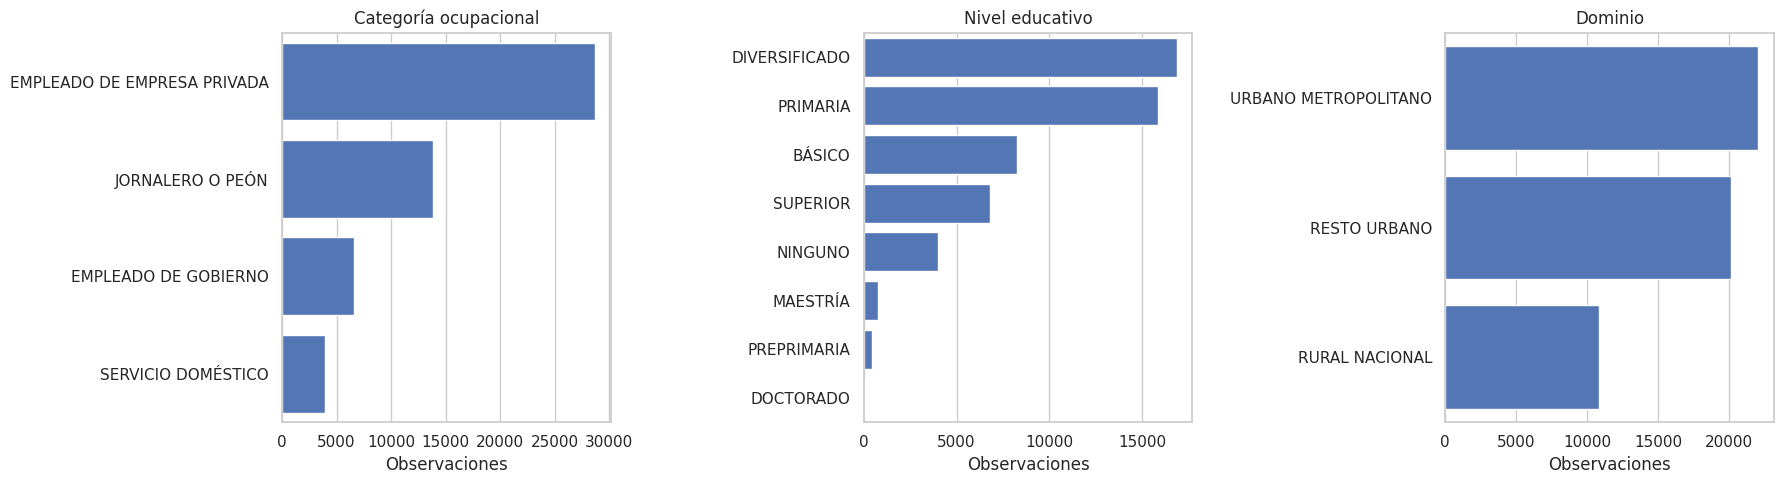

In [10]:
def distribucion(c):
    return eneic_2025.groupBy(c).count().orderBy(F.desc("count")).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, variable, titulo in zip(
    axes,
    ["categoria_ocupacional", "nivel_educativo", "dominio"],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"]
):
    tabla = distribucion(variable)
    sns.barplot(data=tabla, y=variable, x="count", ax=ax, color="#4472C4")
    ax.set_title(titulo); ax.set_xlabel("Observaciones"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

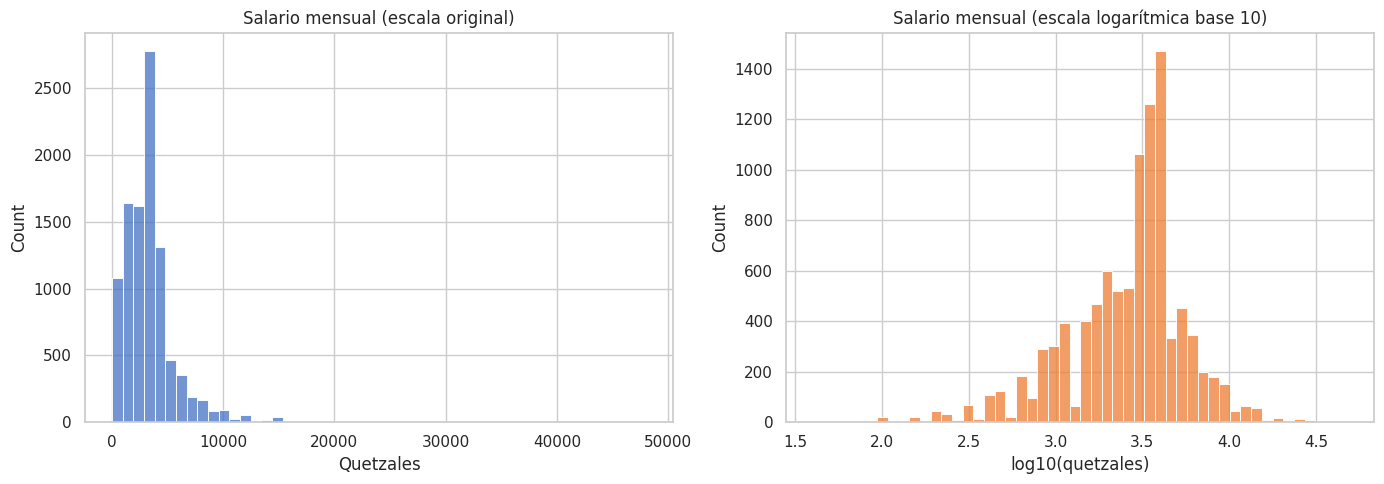

In [11]:
muestra_salario = (eneic_2025.select("salario_mensual")
                   .orderBy(F.rand(seed=42)).limit(10000).toPandas())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(muestra_salario, x="salario_mensual", bins=50, ax=axes[0], color="#4472C4")
axes[0].set_title("Salario mensual (escala original)"); axes[0].set_xlabel("Quetzales")
sns.histplot(np.log10(muestra_salario["salario_mensual"]), bins=50, ax=axes[1], color="#ED7D31")
axes[1].set_title("Salario mensual (escala logarítmica base 10)"); axes[1].set_xlabel("log10(quetzales)")
plt.tight_layout(); plt.show()

,nivel_educativo,n,salario_mediano
0,DOCTORADO,60,12000.0
1,MAESTRÍA,771,10000.0
2,SUPERIOR,6818,5000.0
3,DIVERSIFICADO,16851,3600.0
4,BÁSICO,8249,2800.0
5,PRIMARIA,15822,2200.0
6,PREPRIMARIA,459,2160.0
7,NINGUNO,3995,1500.0


,categoria_ocupacional,n,salario_mediano
0,EMPLEADO DE GOBIERNO,6575,5000.0
1,EMPLEADO DE EMPRESA PRIVADA,28702,3560.0
2,JORNALERO O PEÓN,13842,1800.0
3,SERVICIO DOMÉSTICO,3906,1000.0


,periodo_archivo,n,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


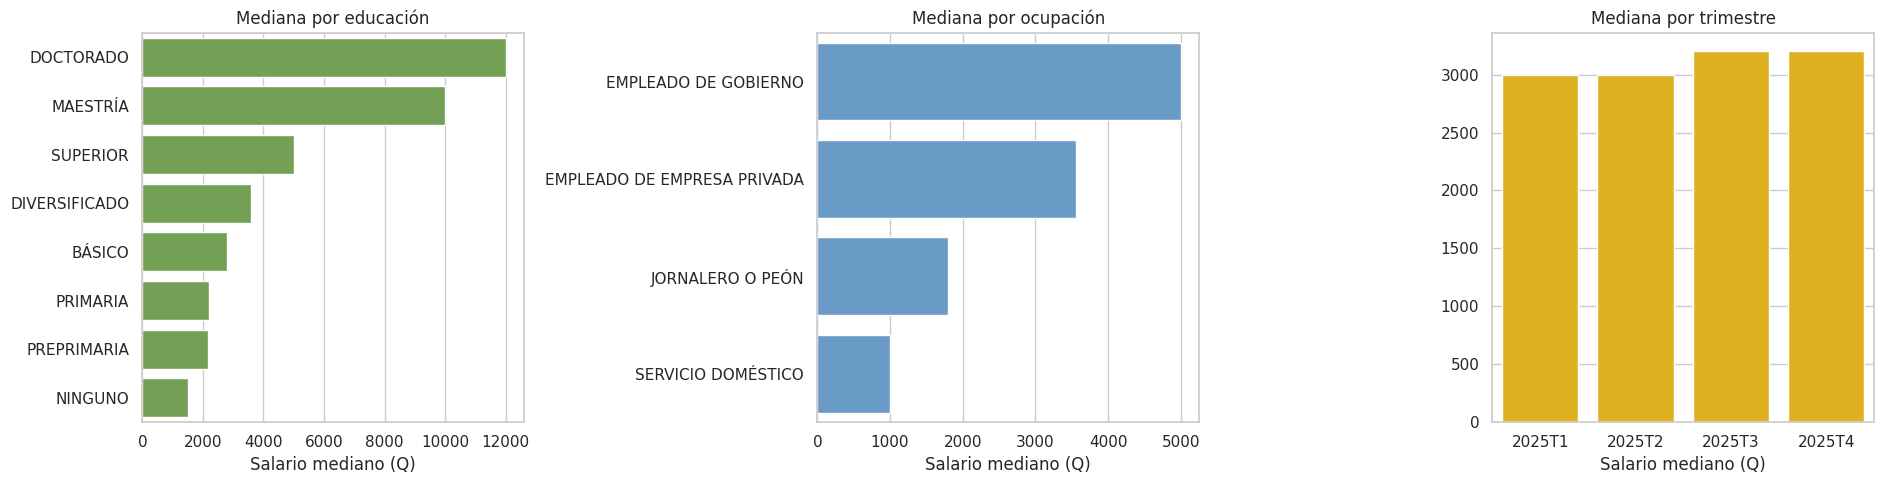

In [12]:
def mediana_grupo(grupo):
    return (eneic_2025.groupBy(grupo)
            .agg(F.count("*").alias("n"), F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"))
            .orderBy(F.desc("salario_mediano")).toPandas())

mediana_educacion = mediana_grupo("nivel_educativo")
mediana_ocupacion = mediana_grupo("categoria_ocupacional")
trimestres = (eneic_2025.groupBy("periodo_archivo")
              .agg(F.count("*").alias("n"), F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"))
              .orderBy("periodo_archivo").toPandas())
display(mediana_educacion.round(2)); display(mediana_ocupacion.round(2)); display(trimestres.round(2))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.barplot(data=mediana_educacion, y="nivel_educativo", x="salario_mediano", ax=axes[0], color="#70AD47")
sns.barplot(data=mediana_ocupacion, y="categoria_ocupacional", x="salario_mediano", ax=axes[1], color="#5B9BD5")
sns.barplot(data=trimestres, x="periodo_archivo", y="salario_mediano", ax=axes[2], color="#FFC000")
axes[0].set_title("Mediana por educación"); axes[1].set_title("Mediana por ocupación"); axes[2].set_title("Mediana por trimestre")
for ax in axes: ax.set_xlabel("Salario mediano (Q)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Interpretación exploratoria.** En 53,025 observaciones, el salario medio (Q3,421.68) supera a la mediana (Q3,000) y el máximo alcanza Q99,000; esto confirma una asimetría positiva. La mediana aumenta con la educación: pasa de Q1,500 sin escolaridad a Q5,000 en educación superior, aunque maestría y doctorado tienen muestras pequeñas. También varía por categoría, desde Q1,000 en servicio doméstico hasta Q5,000 en empleo público. La muestra trimestral baja de 13,492 registros en 2025T2 a 12,664 en 2025T4, mientras la mediana sube de Q3,000 a Q3,200. Estas son asociaciones descriptivas y pueden reflejar cambios de composición.

## 3. Relaciones entre variables numéricas

Se calcula la correlación de Pearson sobre todos los registros elegibles de 2025 mediante `VectorAssembler` y `Correlation.corr()`.

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


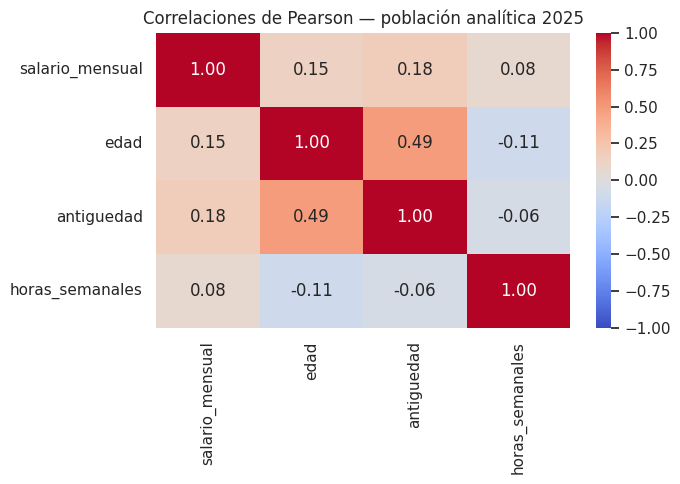

In [13]:
cor_vars = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
cor_vector = VectorAssembler(inputCols=cor_vars, outputCol="cor_features").transform(eneic_2025)
matriz = Correlation.corr(cor_vector, "cor_features", "pearson").first()[0].toArray()
cor_df = pd.DataFrame(matriz, index=cor_vars, columns=cor_vars)
display(cor_df.round(3))
plt.figure(figsize=(7, 5))
sns.heatmap(cor_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlaciones de Pearson — población analítica 2025")
plt.tight_layout(); plt.show()

La antigüedad presenta la mayor asociación lineal con el salario, aunque es débil (r = 0.180); le siguen edad (r = 0.147) y horas semanales (r = 0.076). Edad y antigüedad tienen una relación moderada (r = 0.487), coherente con el tiempo disponible para acumular experiencia. Estas correlaciones no demuestran causalidad.

## 4. Segmentación de perfiles con KMeans

Se comparan dos especificaciones: variables laborales y demográficas (`edad`, `antiguedad`, `horas_semanales`) y las mismas variables más `salario_mensual`. Todas se estandarizan para evitar que sus unidades determinen las distancias. Se evalúan K = 2, 3, 4 y 5 con silueta euclidiana; se usa semilla fija.

especificación,Con salario,Sin salario
k,,
2,0.5118,0.5536
3,0.4911,0.4203
4,0.3756,0.4765
5,0.4088,0.4839


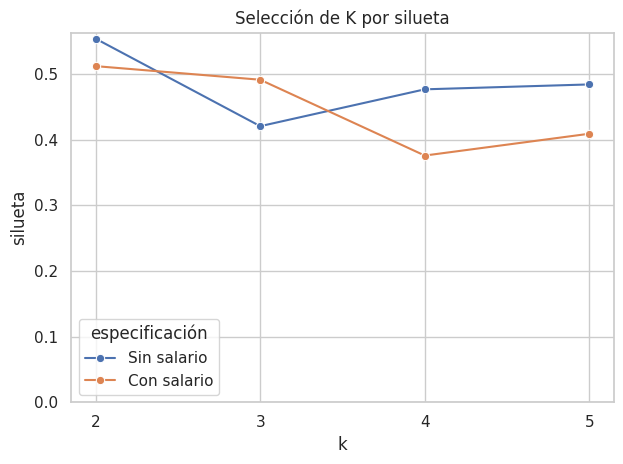

In [14]:
especificaciones = {
    "Sin salario": ["edad", "antiguedad", "horas_semanales"],
    "Con salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
}
resultados_k = []
modelos_k = {}
evaluator = ClusteringEvaluator(featuresCol="scaled_features", predictionCol="cluster", metricName="silhouette")

for nombre, cols in especificaciones.items():
    assembler = VectorAssembler(inputCols=cols, outputCol="raw_features")
    scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withMean=True, withStd=True)
    base_escalada = Pipeline(stages=[assembler, scaler]).fit(eneic_2025).transform(eneic_2025).cache()
    for k in [2, 3, 4, 5]:
        modelo = KMeans(k=k, seed=42, featuresCol="scaled_features", predictionCol="cluster").fit(base_escalada)
        pred = modelo.transform(base_escalada)
        silueta = evaluator.evaluate(pred)
        resultados_k.append((nombre, k, silueta))
        modelos_k[(nombre, k)] = (modelo, base_escalada)

siluetas = pd.DataFrame(resultados_k, columns=["especificación", "k", "silueta"])
display(siluetas.pivot(index="k", columns="especificación", values="silueta").round(4))
sns.lineplot(data=siluetas, x="k", y="silueta", hue="especificación", marker="o")
plt.title("Selección de K por silueta"); plt.xticks([2, 3, 4, 5]); plt.ylim(0, None)
plt.tight_layout(); plt.show()

In [15]:
# El salario se reserva para describir los perfiles, no para construirlos: así los clústeres
# representan condiciones personales/laborales y no se vuelven principalmente estratos de ingreso.
mejor_fila = siluetas[siluetas["especificación"] == "Sin salario"].sort_values("silueta", ascending=False).iloc[0]
mejor_k = int(mejor_fila["k"])
modelo_final, base_final = modelos_k[("Sin salario", mejor_k)]
segmentados = modelo_final.transform(base_final).cache()
print(f"Modelo elegido: sin salario, K={mejor_k}, silueta={mejor_fila['silueta']:.4f}")

perfiles = (segmentados.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.avg("edad").alias("edad_media"),
    F.avg("antiguedad").alias("antiguedad_media"),
    F.avg("horas_semanales").alias("horas_media"),
    F.avg("salario_mensual").alias("salario_medio"),
    F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"),
).orderBy("cluster").toPandas())
perfiles["porcentaje"] = 100 * perfiles["n"] / perfiles["n"].sum()
display(perfiles.round(2))

Modelo elegido: sin salario, K=2, silueta=0.5536


,cluster,n,edad_media,antiguedad_media,horas_media,salario_medio,salario_mediano,porcentaje
0,0,14672,51.25,13.76,41.27,4065.76,3450.0,27.67
1,1,38353,29.04,2.42,48.24,3175.29,3000.0,72.33


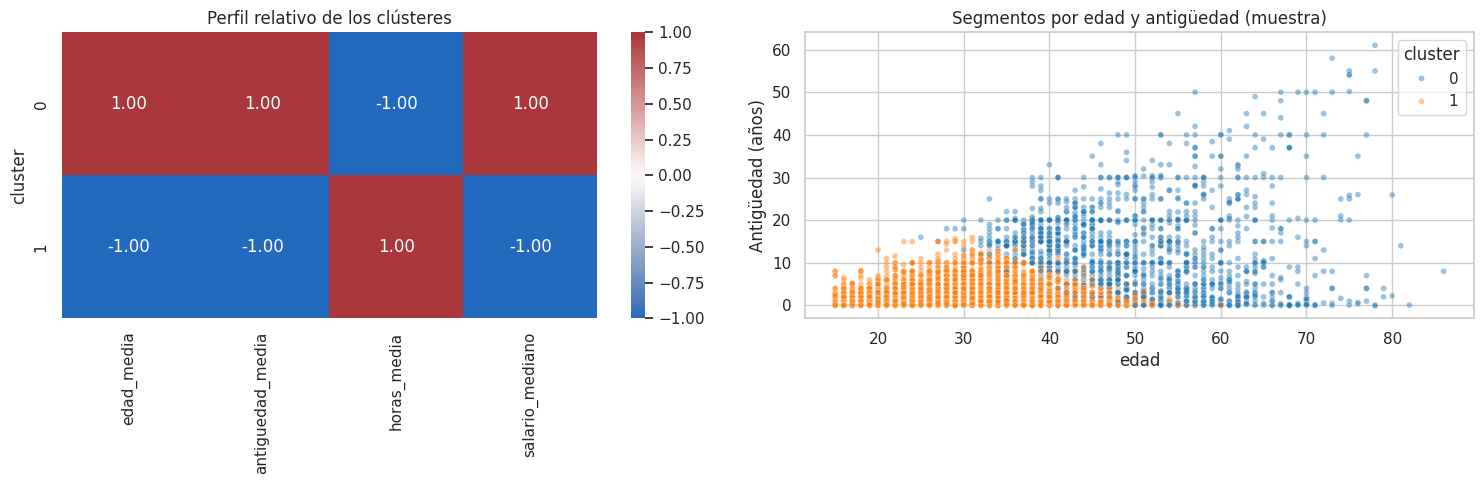

In [16]:
perfil_z = perfiles.set_index("cluster")[["edad_media", "antiguedad_media", "horas_media", "salario_mediano"]]
perfil_z = (perfil_z - perfil_z.mean()) / perfil_z.std(ddof=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(perfil_z, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Perfil relativo de los clústeres")
muestra_cluster = segmentados.select("edad", "antiguedad", "cluster").orderBy(F.rand(seed=42)).limit(5000).toPandas()
sns.scatterplot(data=muestra_cluster, x="edad", y="antiguedad", hue="cluster", palette="tab10", alpha=.45, s=18, ax=axes[1])
axes[1].set_title("Segmentos por edad y antigüedad (muestra)")
axes[1].set_ylabel("Antigüedad (años)")
plt.tight_layout(); plt.show()

**Decisión metodológica.** Se eligió K = 2 sin salario porque obtuvo la mayor silueta de esa especificación (0.5544), superior a K = 3, 4 y 5. Incluir salario redujo la mejor silueta a 0.5136 y podía hacer que la cola salarial dominara la segmentación. El salario se reserva para describir los perfiles y para el modelado supervisado posterior.

- **Clúster 0 — mayor edad y estabilidad:** 27.55% de los registros; edad media de 51.28 años, 13.80 años de antigüedad y 41.30 horas semanales. Su salario mediano es Q3,466.
- **Clúster 1 — jóvenes con menor antigüedad y jornada extensa:** 72.45%; edad media de 29.07 años, 2.42 años de antigüedad y 48.21 horas semanales. Su salario mediano es Q3,000.

**Alcance.** Los clústeres son perfiles descriptivos de similitud, no clases naturales ni explicaciones causales. Su resultado depende de las variables, la estandarización y K.

## Conclusiones del avance

- La armonización por nombre fue indispensable por el cambio de 270 a 302 columnas en 2025T4.
- El filtrado define una población específica de asalariados con información válida; los resultados son muestrales y no ponderados.
- La distribución salarial es asimétrica, por lo que la mediana complementa mejor a la media.
- La correlación resume asociaciones lineales, mientras KMeans permite comparar perfiles multivariados; ninguno de los dos métodos demuestra causalidad.
- El conjunto 2026T1 quedó preparado y separado para la evaluación final, sin utilizarlo para definir la segmentación de 2025.

# Modelado supervisado del salario mensual

**Nicolás Concuá — 23197**

Se estima `salario_mensual` con exactamente seis predictores: `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional` y `dominio`. No se usan identificadores, `FACTOR`, otros ingresos ni la etiqueta de clúster.

**Esquema de partición.** Siguiendo el uso indicado para cada archivo:

- **Entrenamiento:** 2025T1, 2025T2 y 2025T3.
- **Validación:** 2025T4, usado solo para elegir la configuración de cada algoritmo.
- **Entrenamiento final:** los cuatro trimestres de 2025 con la configuración elegida.
- **Prueba final:** 2026T1, que no interviene en ninguna decisión previa.

Todos los componentes de cada pipeline (indexadores, codificadores, escalador y modelo) se ajustan únicamente con el conjunto de entrenamiento correspondiente. El objetivo se mantiene en quetzales, sin transformaciones ni recortes de extremos.

In [17]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

MODELS_DIR = ROOT / "models"
OUTPUTS_DIR = ROOT / "outputs"
MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

TARGET = "salario_mensual"
NUMERIC = ["edad", "antiguedad", "horas_semanales"]
CATEGORICAL = ["nivel_educativo", "categoria_ocupacional", "dominio"]
MODEL_COLS = KEY + [TARGET] + NUMERIC + CATEGORICAL

# Se leen los Parquet guardados en la actividad 1
data_2025 = spark.read.parquet(str(PROCESSED_DIR / "eneic_2025_preparada.parquet")).select(*MODEL_COLS)
test_df = spark.read.parquet(str(PROCESSED_DIR / "eneic_2026T1_preparada.parquet")).select(*MODEL_COLS).cache()

train_df = data_2025.filter(F.col("periodo_archivo") != "2025T4").cache()
valid_df = data_2025.filter(F.col("periodo_archivo") == "2025T4").cache()
full_train_df = data_2025.cache()

split_sizes = pd.DataFrame({
    "conjunto": ["Entrenamiento (2025T1-T3)", "Validación (2025T4)", "Entrenamiento final (2025)", "Prueba (2026T1)"],
    "registros": [train_df.count(), valid_df.count(), full_train_df.count(), test_df.count()],
})
display(split_sizes)

,conjunto,registros
0,Entrenamiento (2025T1-T3),40361
1,Validación (2025T4),12664
2,Entrenamiento final (2025),53025
3,Prueba (2026T1),13258


### Métricas y modelo de referencia

Se reportan MAE, RMSE y R² en quetzales. El **modelo de referencia** predice para todos la media del salario del conjunto de entrenamiento; su R² es cercano a cero por construcción y sirve para saber cuánto aportan realmente los predictores.

In [18]:
def regression_metrics(pred_df, label=TARGET, prediction="prediction"):
    metrics = {}
    for name in ["mae", "rmse", "r2"]:
        evaluator = RegressionEvaluator(labelCol=label, predictionCol=prediction, metricName=name)
        metrics[name.upper() if name != "r2" else "R2"] = evaluator.evaluate(pred_df)
    return metrics


def baseline_predictions(fit_df, eval_df):
    mean_salary = fit_df.agg(F.avg(TARGET)).first()[0]
    return eval_df.withColumn("prediction", F.lit(mean_salary)), mean_salary


baseline_valid, baseline_value = baseline_predictions(train_df, valid_df)
baseline_valid_metrics = regression_metrics(baseline_valid)
print(f"Predicción constante (media de entrenamiento): Q{baseline_value:,.2f}")
display(pd.DataFrame([baseline_valid_metrics], index=["Referencia — validación"]).round(3))

Predicción constante (media de entrenamiento): Q3,383.12


,MAE,RMSE,R2
Referencia — validación,1672.503,2889.571,-0.003


## 5. Pipeline de regresión lineal

Etapas del pipeline:

a. `StringIndexer` (`handleInvalid="keep"`, para tolerar categorías no vistas) y `OneHotEncoder` para nivel educativo, categoría ocupacional y dominio.
b. `VectorAssembler` que combina edad, antigüedad y horas semanales con las variables codificadas.
c. `StandardScaler` (media 0 y desviación 1) para que la penalización trate a todos los coeficientes en la misma escala.
d. `LinearRegression`.

Se prueban seis configuraciones de regularización: sin penalización, Ridge (`elasticNetParam = 0`), Lasso (`elasticNetParam = 1`) y Elastic Net (`elasticNetParam = 0.5`), con distintos valores de `regParam`. Se elige la de menor RMSE en validación.

In [19]:
def feature_stages():
    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL]
    encoder = OneHotEncoder(inputCols=[f"{c}_idx" for c in CATEGORICAL],
                            outputCols=[f"{c}_ohe" for c in CATEGORICAL], handleInvalid="keep")
    assembler = VectorAssembler(inputCols=NUMERIC + [f"{c}_ohe" for c in CATEGORICAL], outputCol="features_raw")
    return indexers + [encoder, assembler]


def lr_pipeline(reg_param, elastic_net):
    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
    lr = LinearRegression(featuresCol="features", labelCol=TARGET, regParam=reg_param,
                          elasticNetParam=elastic_net, standardization=False, maxIter=100)
    return Pipeline(stages=feature_stages() + [scaler, lr])


LR_GRID = [
    {"regParam": 0.0, "elasticNetParam": 0.0},
    {"regParam": 10.0, "elasticNetParam": 0.0},
    {"regParam": 100.0, "elasticNetParam": 0.0},
    {"regParam": 10.0, "elasticNetParam": 1.0},
    {"regParam": 100.0, "elasticNetParam": 1.0},
    {"regParam": 50.0, "elasticNetParam": 0.5},
]

lr_results = []
for params in LR_GRID:
    model = lr_pipeline(params["regParam"], params["elasticNetParam"]).fit(train_df)
    lr_results.append({**params, **regression_metrics(model.transform(valid_df))})

lr_results = pd.DataFrame(lr_results).sort_values("RMSE").reset_index(drop=True)
display(lr_results.round(3))
best_lr_params = lr_results.iloc[0][["regParam", "elasticNetParam"]].to_dict()
print("Mejor configuración de regresión lineal:", best_lr_params)

,regParam,elasticNetParam,MAE,RMSE,R2
0,0.0,0.0,1210.137,2186.420,0.426
1,10.0,0.0,1209.670,2186.551,0.426
2,10.0,1.0,1206.184,2187.291,0.425
3,100.0,0.0,1205.931,2188.062,0.425
4,50.0,0.5,1200.484,2190.126,0.424
5,100.0,1.0,1197.953,2213.102,0.412


Mejor configuración de regresión lineal: {'regParam': 0.0, 'elasticNetParam': 0.0}


In [20]:
best_lr_valid_model = lr_pipeline(best_lr_params["regParam"], best_lr_params["elasticNetParam"]).fit(train_df)
lr_valid_metrics = regression_metrics(best_lr_valid_model.transform(valid_df))
best_lr_valid_model.write().overwrite().save(str(MODELS_DIR / "lr_best_validation"))

display(pd.DataFrame([baseline_valid_metrics, lr_valid_metrics],
                     index=["Referencia (media)", "Regresión lineal"]).round(3))


def feature_names(pipeline_model, df=train_df):
    # Nombres en el mismo orden que el vector, tomados de los metadatos de VectorAssembler
    schema = pipeline_model.transform(df.limit(1)).schema["features_raw"]
    attrs = schema.metadata["ml_attr"]["attrs"]
    ordered = sorted([a for group in attrs.values() for a in group], key=lambda a: a["idx"])
    return [a["name"] for a in ordered]


lr_stage = best_lr_valid_model.stages[-1]
coefficients = (pd.DataFrame({"variable": feature_names(best_lr_valid_model),
                              "coeficiente_estandarizado": lr_stage.coefficients.toArray()})
                .assign(magnitud=lambda d: d["coeficiente_estandarizado"].abs())
                .sort_values("magnitud", ascending=False).drop(columns="magnitud"))
print(f"Intercepto: Q{lr_stage.intercept:,.2f}")
display(coefficients.head(12).round(2))

,MAE,RMSE,R2
Referencia (media),1672.503,2889.571,-0.003
Regresión lineal,1210.137,2186.420,0.426


Intercepto: Q3,383.12


,variable,coeficiente_estandarizado
8,nivel_educativo_ohe_MAESTRÍA,829.87
6,nivel_educativo_ohe_SUPERIOR,592.06
14,categoria_ocupacional_ohe_EMPLEADO DE GOBIERNO,466.73
15,categoria_ocupacional_ohe_SERVICIO DOMÉSTICO,-366.57
4,nivel_educativo_ohe_PRIMARIA,-344.97
7,nivel_educativo_ohe_NINGUNO,-330.72
2,horas_semanales,303.58
10,nivel_educativo_ohe_DOCTORADO,299.93
0,edad,275.57
13,categoria_ocupacional_ohe_JORNALERO O PEÓN,-270.40


**Interpretación.** Las seis configuraciones quedaron prácticamente empatadas en validación (RMSE entre Q2,186 y Q2,213). La menor RMSE fue la regresión **sin penalización** (`regParam = 0`), con MAE = Q1,210, RMSE = Q2,186 y R² = 0.426. La regularización casi no cambia el resultado: hay unos 40 mil registros y pocas columnas de features, así que no hay sobreajuste que corregir. El Lasso más fuerte (`regParam = 100`, `elasticNetParam = 1`) baja un poco el MAE, pero sube el RMSE porque encoge los coeficientes que explican los salarios altos.

Frente al modelo de referencia (RMSE = Q2,890, R² ≈ 0), la regresión lineal reduce el RMSE en unos Q700 y el MAE en unos Q460, y explica cerca del 43 % de la varianza del salario en 2025T4. Como los predictores están estandarizados, el intercepto coincide con el salario medio de entrenamiento y los coeficientes se leen como el cambio en quetzales por una desviación estándar de cada variable. Los más grandes corresponden a tener maestría o educación superior y a ser empleado de gobierno (positivos), y a servicio doméstico, jornalero o nivel educativo bajo (negativos); esto coincide con las medianas de la actividad 2. Las variables numéricas (horas, edad y antigüedad) pesan menos que las categorías de educación y ocupación. Aun así, el error típico de más de Q2,000 es alto frente a una mediana de Q3,000: el modelo es aditivo y no capta interacciones ni la cola de salarios altos.

## 6. Pipeline de Random Forest

Se reutilizan las mismas etapas de codificación (a y b) y el mismo par entrenamiento/validación. `RandomForestRegressor` no necesita estandarización. Se varían el número de árboles (`numTrees`) y la profundidad máxima (`maxDepth`), con semilla fija `seed = 42`, y se elige la configuración con menor RMSE en validación.

In [21]:
def rf_pipeline(num_trees, max_depth):
    rf = RandomForestRegressor(featuresCol="features_raw", labelCol=TARGET, numTrees=num_trees,
                               maxDepth=max_depth, minInstancesPerNode=5, seed=42)
    return Pipeline(stages=feature_stages() + [rf])


RF_GRID = [
    {"numTrees": 50, "maxDepth": 5},
    {"numTrees": 100, "maxDepth": 5},
    {"numTrees": 50, "maxDepth": 10},
    {"numTrees": 100, "maxDepth": 10},
    {"numTrees": 100, "maxDepth": 15},
    {"numTrees": 100, "maxDepth": 20},
]

rf_results = []
for params in RF_GRID:
    model = rf_pipeline(params["numTrees"], params["maxDepth"]).fit(train_df)
    rf_results.append({**params, **regression_metrics(model.transform(valid_df))})

rf_results = pd.DataFrame(rf_results).sort_values("RMSE").reset_index(drop=True)
display(rf_results.round(3))
best_rf_params = {k: int(v) for k, v in rf_results.iloc[0][["numTrees", "maxDepth"]].to_dict().items()}
print("Mejor configuración de Random Forest:", best_rf_params)

,numTrees,maxDepth,MAE,RMSE,R2
0,100,20,1051.789,1972.355,0.533
1,100,15,1059.197,1981.242,0.528
2,50,10,1081.833,2016.933,0.511
3,100,10,1081.428,2021.651,0.509
4,100,5,1159.774,2161.933,0.438
5,50,5,1165.618,2164.218,0.437


Mejor configuración de Random Forest: {'numTrees': 100, 'maxDepth': 20}


,MAE,RMSE,R2
Referencia (media),1672.503,2889.571,-0.003
Regresión lineal,1210.137,2186.420,0.426
Random Forest,1051.789,1972.355,0.533


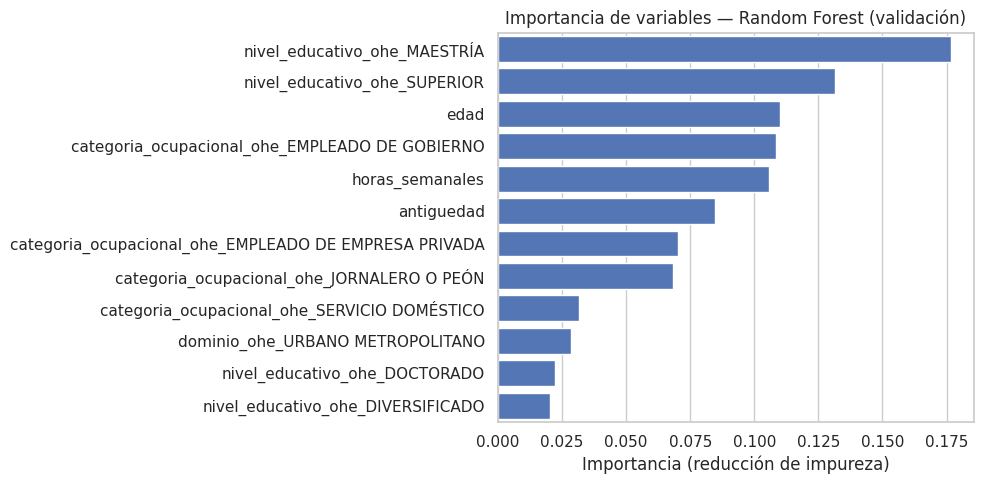

In [22]:
best_rf_valid_model = rf_pipeline(best_rf_params["numTrees"], best_rf_params["maxDepth"]).fit(train_df)
rf_valid_metrics = regression_metrics(best_rf_valid_model.transform(valid_df))
best_rf_valid_model.write().overwrite().save(str(MODELS_DIR / "rf_best_validation"))

valid_comparison = pd.DataFrame([baseline_valid_metrics, lr_valid_metrics, rf_valid_metrics],
                                index=["Referencia (media)", "Regresión lineal", "Random Forest"])
display(valid_comparison.round(3))

importances = (pd.DataFrame({"variable": feature_names(best_rf_valid_model),
                             "importancia": best_rf_valid_model.stages[-1].featureImportances.toArray()})
               .sort_values("importancia", ascending=False))
plt.figure(figsize=(10, 5))
sns.barplot(data=importances.head(12), y="variable", x="importancia", color="#4472C4")
plt.title("Importancia de variables — Random Forest (validación)")
plt.xlabel("Importancia (reducción de impureza)"); plt.ylabel("")
plt.tight_layout(); plt.savefig(OUTPUTS_DIR / "rf_importancias.png", dpi=150); plt.show()

**Interpretación.** El desempeño mejora con la profundidad: pasar de 5 a 10 niveles baja el RMSE de validación de unos Q2,160 a unos Q2,020, y llegar a 20 lo deja en **Q1,972** (MAE = Q1,052, R² = 0.533). De 15 a 20 la ganancia ya es marginal (Q9 de RMSE), señal de que el modelo se acerca a su techo con estos seis predictores. Con profundidad 5, 50 y 100 árboles dan resultados casi iguales, así que la profundidad importa más que el número de árboles. Se elige **100 árboles con profundidad 20**.

**Random Forest supera a la regresión lineal** en validación en las tres métricas: unos Q210 menos de RMSE, Q160 menos de MAE y 11 puntos más de R². Ambos superan con claridad a la referencia. La diferencia se explica porque los árboles modelan **interacciones y no linealidades** sin especificarlas (por ejemplo, el efecto de la educación depende de la categoría ocupacional y del dominio, y el salario no crece linealmente con la edad). La regresión lineal, en cambio, supone efectos aditivos y constantes. Las importancias confirman que educación alta (maestría, superior), horas, edad, empleo público y antigüedad concentran la mayor parte de la información; el dominio aporta poco una vez controladas las demás variables. Random Forest también promedia las predicciones de sus hojas, así que no puede extrapolar por encima de los salarios vistos en entrenamiento: eso limita su capacidad para salarios extremos.

## 7. Entrenamiento final y evaluación en 2026T1

Con la configuración elegida para cada algoritmo, cada pipeline se vuelve a ajustar con los cuatro trimestres de 2025 (entrenamiento + validación). Luego se predice 2026T1, preparado con exactamente las mismas reglas de la actividad 1. Ambos modelos y la referencia se evalúan sobre los mismos registros.

In [23]:
final_lr = lr_pipeline(best_lr_params["regParam"], best_lr_params["elasticNetParam"]).fit(full_train_df)
final_rf = rf_pipeline(best_rf_params["numTrees"], best_rf_params["maxDepth"]).fit(full_train_df)
final_lr.write().overwrite().save(str(MODELS_DIR / "lr_final"))
final_rf.write().overwrite().save(str(MODELS_DIR / "rf_final"))

pred_cols = KEY + [TARGET] + NUMERIC + CATEGORICAL
test_pred = (final_lr.transform(test_df).select(*pred_cols, F.col("prediction").alias("pred_lr"))
             .join(final_rf.transform(test_df).select(*KEY, F.col("prediction").alias("pred_rf")), KEY, "inner"))
baseline_test_value = full_train_df.agg(F.avg(TARGET)).first()[0]
test_pred = (test_pred
             .withColumn("pred_base", F.lit(baseline_test_value))
             .withColumn("resid_lr", F.col(TARGET) - F.col("pred_lr"))
             .withColumn("resid_rf", F.col(TARGET) - F.col("pred_rf"))
             .cache())

n_test, n_pred = test_df.count(), test_pred.count()
print(f"Registros elegibles de prueba: {n_test:,}; con predicción de ambos modelos: {n_pred:,}")

test_comparison = pd.DataFrame(
    [regression_metrics(test_pred, prediction=p) for p in ["pred_base", "pred_lr", "pred_rf"]],
    index=["Referencia (media 2025)", "Regresión lineal", "Random Forest"])
display(test_comparison.round(3))

Registros elegibles de prueba: 13,258; con predicción de ambos modelos: 13,258


,MAE,RMSE,R2
Referencia (media 2025),1718.086,2871.421,-0.003
Regresión lineal,1240.711,2163.752,0.431
Random Forest,1079.509,1937.800,0.543


**Interpretación.** Los dos modelos y la referencia se evaluaron exactamente sobre los mismos **13,258 registros elegibles de 2026T1**, y ninguno se usó para elegir hiperparámetros. El orden de validación se mantiene: **Random Forest** obtiene MAE = Q1,080, RMSE = Q1,938 y R² = 0.543; la **regresión lineal**, MAE = Q1,241, RMSE = Q2,164 y R² = 0.431; y la referencia (media de 2025), RMSE = Q2,871 y R² ≈ 0. Las métricas de prueba son iguales o incluso un poco mejores que las de validación, así que no hay señal de sobreajuste. Además, la relación entre las seis variables y el salario fue estable de 2025 a 2026T1. Aun con el mejor modelo, el error absoluto medio equivale a cerca de un tercio del salario mediano (Q3,200 en 2026T1): los predictores disponibles explican algo más de la mitad de la variabilidad.

## 8. Visualización y análisis de errores

El residuo se define como **residuo = salario real − salario predicho**. Un residuo positivo indica que el modelo **subestimó**; uno negativo, que **sobreestimó**. Para los gráficos se usa la **misma muestra aleatoria de 5,000 registros de prueba** en ambos modelos; las tablas por grupo y por percentil usan los 13,258 registros de prueba.

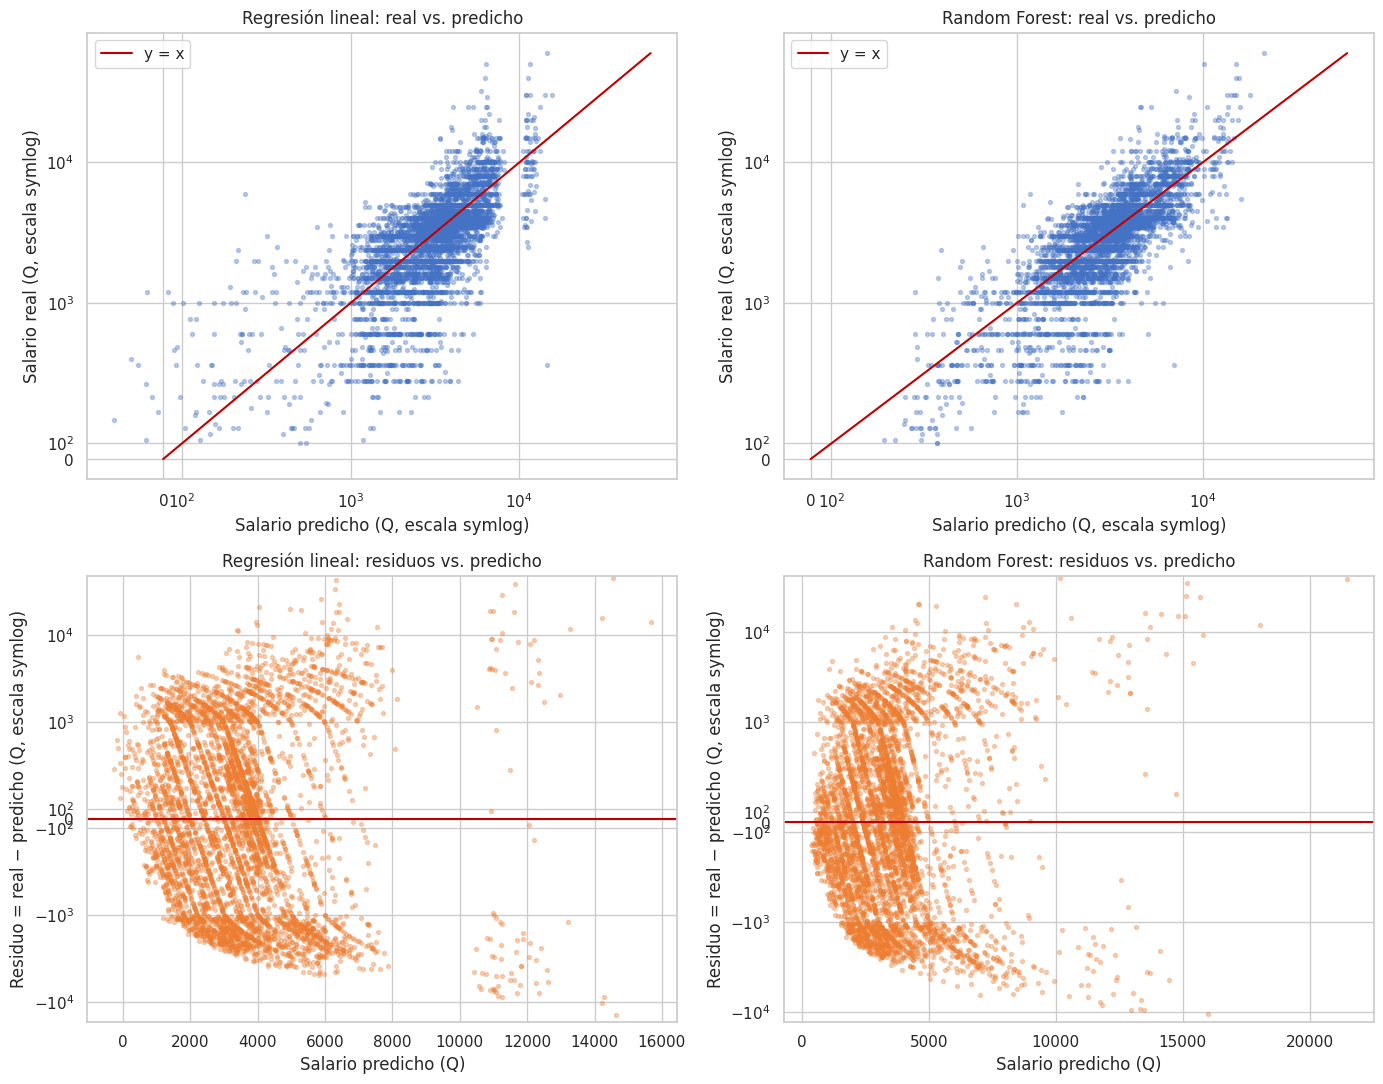

In [24]:
plot_sample = test_pred.orderBy(F.rand(seed=42)).limit(5000).toPandas()
models = [("pred_lr", "resid_lr", "Regresión lineal"), ("pred_rf", "resid_rf", "Random Forest")]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
upper = plot_sample[[TARGET, "pred_lr", "pred_rf"]].max().max()
for col, (pred, resid, name) in enumerate(models):
    ax = axes[0, col]
    ax.scatter(plot_sample[pred], plot_sample[TARGET], s=8, alpha=.35, color="#4472C4")
    ax.plot([0, upper], [0, upper], color="#C00000", lw=1.5, label="y = x")
    ax.set_xscale("symlog", linthresh=1000); ax.set_yscale("symlog", linthresh=1000)
    ax.set_title(f"{name}: real vs. predicho"); ax.set_xlabel("Salario predicho (Q, escala symlog)")
    ax.set_ylabel("Salario real (Q, escala symlog)"); ax.legend()

    ax = axes[1, col]
    ax.scatter(plot_sample[pred], plot_sample[resid], s=8, alpha=.35, color="#ED7D31")
    ax.axhline(0, color="#C00000", lw=1.5)
    ax.set_yscale("symlog", linthresh=1000)
    ax.set_title(f"{name}: residuos vs. predicho"); ax.set_xlabel("Salario predicho (Q)")
    ax.set_ylabel("Residuo = real − predicho (Q, escala symlog)")
plt.tight_layout(); plt.savefig(OUTPUTS_DIR / "real_vs_predicho_residuos.png", dpi=150); plt.show()

Los ejes usan escala *symlog* (lineal cerca de cero y logarítmica en valores grandes) solo para que la cola salarial no aplaste la nube principal; los valores siguen en quetzales.

In [25]:
def group_errors(group):
    return (test_pred.groupBy(group).agg(
                F.count("*").alias("n"),
                F.avg(F.abs("resid_lr")).alias("MAE_lr"),
                F.avg("resid_lr").alias("error_medio_lr"),
                F.avg(F.abs("resid_rf")).alias("MAE_rf"),
                F.avg("resid_rf").alias("error_medio_rf"))
            .orderBy(F.desc("n")).toPandas())


errors_education = group_errors("nivel_educativo")
errors_domain = group_errors("dominio")
display(errors_education.round(1))
display(errors_domain.round(1))

,nivel_educativo,n,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
0,DIVERSIFICADO,4117,1109.3,104.0,995.5,101.7
1,PRIMARIA,3957,870.0,54.6,740.9,55.3
2,BÁSICO,2164,894.5,127.8,786.4,126.6
3,SUPERIOR,1729,2566.4,295.5,2252.4,246.3
4,NINGUNO,1016,823.5,109.3,620.3,56.5
5,MAESTRÍA,183,5552.9,-131.5,4736.8,-331.7
6,PREPRIMARIA,80,735.2,88.8,579.4,29.2
7,DOCTORADO,12,12919.3,6062.7,11869.6,7469.3


,dominio,n,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
0,URBANO METROPOLITANO,5632,1446.1,136.0,1301.8,142.0
1,RESTO URBANO,4846,1189.6,134.3,1011.4,102.0
2,RURAL NACIONAL,2780,913.6,65.2,747.7,47.4


Percentiles del salario real en prueba (Q): {'P25': 2000, 'P50': 3200, 'P75': 4080, 'P90': 6000, 'P95': 8000, 'P99': 15000}


,tramo,n,salario_real_medio,pred_lr_medio,pred_rf_medio,error_medio_lr,error_medio_rf,MAE_lr,MAE_rf
0,≤ P25,4032,1297.7,2126.4,2007.9,-828.7,-710.2,998.4,808.9
1,P25–P50,2715,2738.2,2899.3,2874.5,-161.1,-136.3,851.7,680.1
2,P50–P75,3200,3770.2,3852.3,3825.3,-82.1,-55.1,832.9,746.5
3,P75–P90,2060,4893.3,4400.0,4447.6,493.3,445.7,1176.4,1173.4
4,P90–P95,608,7224.8,5590.5,5805.0,1634.3,1419.8,2076.1,1917.2
5,P95–P99,545,10722.7,6630.9,7354.6,4091.7,3368.1,4331.3,3694.0
6,> P99,98,22730.0,8444.6,10293.6,14285.4,12436.4,14285.4,12436.4


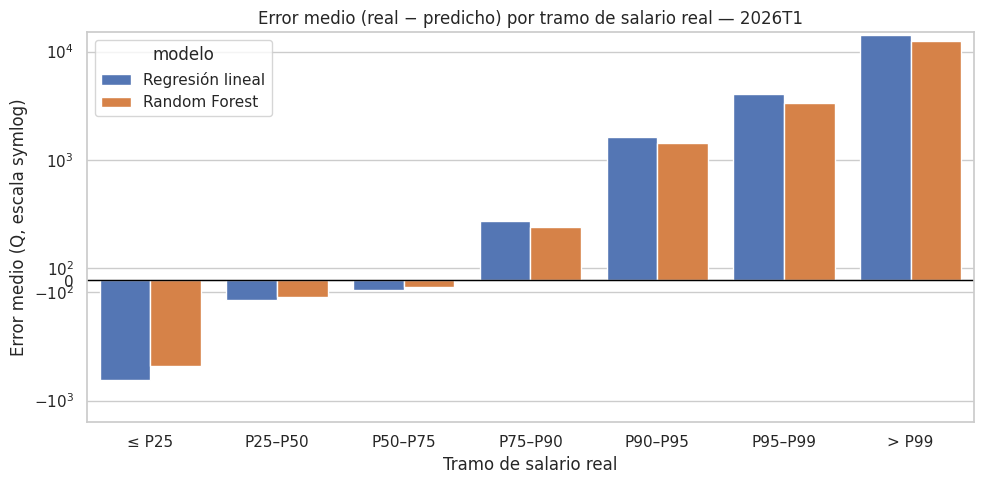

In [26]:
# Error por tramos de salario real, con cortes en percentiles de 2026T1
cuts = test_pred.approxQuantile(TARGET, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99], 0.0)
band_labels = ["≤ P25", "P25–P50", "P50–P75", "P75–P90", "P90–P95", "P95–P99", "> P99"]
band_expr = F.when(F.col(TARGET) <= cuts[0], band_labels[0])
for cut, label in zip(cuts[1:], band_labels[1:-1]):
    band_expr = band_expr.when(F.col(TARGET) <= cut, label)
band_expr = band_expr.otherwise(band_labels[-1])

print("Percentiles del salario real en prueba (Q):",
      dict(zip(["P25", "P50", "P75", "P90", "P95", "P99"], [round(c) for c in cuts])))
errors_band = (test_pred.withColumn("tramo", band_expr).groupBy("tramo").agg(
                   F.count("*").alias("n"),
                   F.avg(TARGET).alias("salario_real_medio"),
                   F.avg("pred_lr").alias("pred_lr_medio"),
                   F.avg("pred_rf").alias("pred_rf_medio"),
                   F.avg("resid_lr").alias("error_medio_lr"),
                   F.avg("resid_rf").alias("error_medio_rf"),
                   F.avg(F.abs("resid_lr")).alias("MAE_lr"),
                   F.avg(F.abs("resid_rf")).alias("MAE_rf"))
               .toPandas())
errors_band["tramo"] = pd.Categorical(errors_band["tramo"], band_labels, ordered=True)
errors_band = errors_band.sort_values("tramo").reset_index(drop=True)
display(errors_band.round(1))

plot_band = errors_band.melt(id_vars="tramo", value_vars=["error_medio_lr", "error_medio_rf"],
                             var_name="modelo", value_name="error_medio")
plot_band["modelo"] = plot_band["modelo"].map({"error_medio_lr": "Regresión lineal", "error_medio_rf": "Random Forest"})
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_band, x="tramo", y="error_medio", hue="modelo", palette=["#4472C4", "#ED7D31"])
plt.axhline(0, color="black", lw=1)
plt.yscale("symlog", linthresh=1000)
plt.title("Error medio (real − predicho) por tramo de salario real — 2026T1")
plt.xlabel("Tramo de salario real"); plt.ylabel("Error medio (Q, escala symlog)")
plt.tight_layout(); plt.savefig(OUTPUTS_DIR / "error_por_percentil.png", dpi=150); plt.show()

### Análisis de errores

**Gráficos real vs. predicho.** En ambos modelos la nube sigue la dirección de la recta y = x, pero con mucha dispersión vertical. Hay franjas horizontales porque muchos salarios se reportan en montos redondos (Q1,000, Q2,000, Q3,000...). Para salarios reales altos, la mayoría de puntos queda por encima de la recta: el salario real es mayor que el predicho. La regresión lineal, al ser aditiva, produce algunas predicciones muy bajas (cercanas a cero) en perfiles con poca edad y pocas horas; Random Forest, al promediar salarios observados, se mantiene dentro del rango visto en entrenamiento.

**Residuos vs. predicho.** Los residuos se abren conforme crece la predicción (heterocedasticidad): el error en quetzales es mayor donde los salarios son más altos. Las líneas diagonales de puntos corresponden a los salarios redondos. En la regresión lineal aparece un grupo separado cerca de Q11,000–Q12,000 predichos, que probablemente corresponde a perfiles con posgrado (los coeficientes más altos del modelo); ahí el modelo asigna un mismo nivel alto a perfiles con salarios muy distintos.

**Errores por grupo.** El MAE crece con el nivel educativo porque también crecen el salario y su dispersión: en Random Forest va de unos Q580–Q740 en primaria, preprimaria o sin escolaridad a Q2,252 en educación superior y Q4,737 en maestría. En doctorado (solo 12 registros) el error medio es de +Q7,469, así que se subestima fuertemente, aunque con tan pocos casos el resultado es poco estable. Por dominio, el MAE es mayor en el urbano metropolitano (Q1,302) que en el resto urbano (Q1,011) y el rural (Q748), otra vez en línea con el nivel y la dispersión salarial de cada dominio. En casi todos los grupos el error medio es positivo, aunque pequeño frente al MAE: hay una leve subestimación promedio, porque los salarios de 2026T1 son algo mayores que los de 2025 y la cola derecha no se reproduce.

**Percentiles del salario real.** La distribución de prueba es muy asimétrica: P25 = Q2,000, P50 = Q3,200, P75 = Q4,080, P90 = Q6,000, P95 = Q8,000 y P99 = Q15,000. Los errores **no son homogéneos** y muestran una clara **regresión hacia la media**:

- Por debajo de P25 ambos modelos **sobreestiman** (error medio de −Q829 en la lineal y −Q710 en Random Forest).
- Entre P25 y P75 el sesgo es pequeño (−Q55 a −Q161).
- A partir de P75 el signo cambia y los modelos **subestiman** cada vez más: +Q446–Q493 en P75–P90, +Q1,420–Q1,634 en P90–P95, +Q3,368–Q4,092 en P95–P99 y más de **+Q12,000** en el 1 % más alto.

Así, los salarios altos se subestiman de forma sistemática. Las seis variables no distinguen a quien gana Q20,000 de quien gana Q6,000 con el mismo perfil educativo y ocupacional. Además, al minimizar el error cuadrático, ambos modelos predicen algo cercano a la media condicional, que queda muy por debajo de esos extremos. Random Forest reduce el sesgo en todos los tramos, pero no lo elimina. Los salarios extremos no se eliminaron; por eso inflan el RMSE mucho más que el MAE (RMSE ≈ 1.8 × MAE).

## Discusión final

1. **Datos y población.** La armonización por nombre de columna, la trazabilidad por archivo y los filtros secuenciales dejaron 53,025 registros de asalariados con salario positivo en 2025 y 13,258 en 2026T1. Los resultados describen esos registros sin ponderar; no son estimaciones oficiales del país (para eso habría que usar `FACTOR` y el diseño muestral).
2. **Exploración.** El salario es muy asimétrico a la derecha (media Q3,422 > mediana Q3,000; máximo Q99,000), así que conviene resumirlo con la mediana. Las diferencias más marcadas se dan por nivel educativo y categoría ocupacional: el empleo público y la educación superior o de posgrado tienen las medianas más altas, y el servicio doméstico y los jornaleros las más bajas.
3. **Relaciones y perfiles.** Las correlaciones lineales de las variables numéricas con el salario son débiles (r ≤ 0.18), y edad y antigüedad están moderadamente asociadas (r ≈ 0.49). KMeans (K = 2, sin salario) separó a trabajadores mayores con alta antigüedad de trabajadores jóvenes con poca antigüedad y jornadas más largas; los primeros tienen un salario mediano algo mayor.
4. **Modelos.** Con solo seis predictores, **Random Forest (100 árboles, profundidad 20)** fue el mejor modelo en validación y en prueba (R² = 0.543, RMSE = Q1,938 en 2026T1), por encima de la **regresión lineal** (R² = 0.431, RMSE = Q2,164) y muy por encima de la referencia. La ventaja viene de captar interacciones y no linealidades; la regularización de la regresión lineal no aportó mejoras.
5. **Errores.** Los dos modelos comprimen las predicciones hacia el centro: **sobreestiman los salarios bajos y subestiman sistemáticamente los altos**, con errores que superan los Q12,000 en el 1 % superior. Los errores absolutos son mayores en los grupos de salarios altos y más dispersos (posgrado, educación superior, área metropolitana).
6. **Limitaciones y mejoras.** Falta información clave para explicar el salario, como la ocupación y la rama de actividad, el tamaño de la empresa, el sexo, el departamento o la formalidad. Un modelado sobre el logaritmo del salario o con pérdidas robustas podría reducir la influencia de la cola, pero la comparación obligatoria se hizo en quetzales y sin recortar extremos, como pide el enunciado.

En conclusión, las características personales y laborales observadas permiten estimar el salario mensual con un error típico de unos Q1,100 (MAE) y explican algo más de la mitad de su variabilidad. Estos modelos sirven para describir patrones promedio, pero no para predecir con precisión salarios individuales, sobre todo los altos. Las asociaciones encontradas no son causales ni indican cuánto debería ganar una persona.

In [27]:
spark.stop()